# Bothwell mm-scale gravitational-redshift case

This notebook walks CliffordClock's second reproducibility case.
Bothwell et al. (Nature 602, 420 (2022) / arXiv:2109.12238) measured
General Relativity's gravitational redshift across a millimetre-scale
Sr-87 optical-lattice sample, the first single-apparatus measurement at
this length scale. This project's `ensemble.regime: lattice_extended`
pipeline is configured to their sample geometry and surveyed local
gravity. It predicts their published per-site slope end to end with
zero adjustable inputs.

In [1]:
%matplotlib inline
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "benchmarks"))

import run_bothwell_redshift as bothwell

from cliffordclock.ensemble import HarmonicTrap, get_species
from cliffordclock.ensemble.lattice import extended_lattice_nodes
from cliffordclock.integrator.omega import grav_pivot_perturbation, height_along_axis
from cliffordclock.pipeline import PipelineConfig, run_pipeline_full

## 1. The physics: the gravitational-redshift pivot term (E36) and the extended-lattice geometry

General Relativity predicts that a clock higher in a gravitational
potential runs faster than one lower down. At laboratory height
differences, this effect is the leading term of the metric proper-time
ratio: a clock's fractional frequency shift relative to a reference
height grows linearly with the height difference, `g*(h - h_ref)/c^2`.
No curvature correction is large enough to matter over a millimetre.
`docs/CONVENTIONS.md`'s E36 (section 15) states this pivot term in
that same form and composes it additively into the same scalar pivot
the DC-Stark, BBR, and quadrupole terms occupy, since it is one more
contribution to the clock's fractional frequency at a point. The other
three terms in that pivot are sourced by an electromagnetic field.
This one is sourced by height, through gravity alone.

What makes Bothwell's measurement a genuine engineering case is the
*sample*. A single lattice site would place one atom at one height,
reducing E36 to a one-line calculation. CliffordClock's
`ensemble.regime: lattice_extended` (section 15's second half)
distributes many copies of the same single-site motional quadrature
along an axis, so each site sits at its own height and picks up its
own E36 shift. The engine then fits the resulting per-site frequency
map the same way Bothwell's own imaging analysis does. The extended
sample turns E36 into a real engineering problem.

## 2. The inputs: sample geometry and surveyed local gravity

Three geometric numbers, plus one gravity value, configure the
extended lattice. Each one traces to a specific published statement or
survey; none is chosen freely to make the fit land. The site spacing
is half the 813 nm magic wavelength that traps Sr-87, since a
standing-wave lattice site sits every half wavelength. The envelope
width comes from Bothwell's own imaging resolution and
analysis-window pixel count. The reference gravity is the
USGS-surveyed local value at the JILA Boulder site.
`docs/CONVENTIONS.md` section 15 states that a standard-gravity
textbook constant is only a placeholder once uniform-g arithmetic is
pushed to the 1e-19 level, so the surveyed value is what this case
uses.

In [2]:
site_spacing_nm = bothwell.SITE_SPACING_M * 1e9
envelope_sigma_um = bothwell.ENVELOPE_SIGMA_M * 1e6
print(f"lattice site spacing:      {site_spacing_nm:.1f} nm (= 813 nm magic wavelength / 2)")
print(f"Gaussian envelope sigma:    {envelope_sigma_um:.1f} um (imaging pixel size + window)")
print(
    f"full computational grid:   {bothwell.N_SITES} sites "
    f"(+/-{bothwell.N_SIGMA_HALF_SPAN} sigma of the envelope)"
)
print(f"surveyed local gravity:    {bothwell.BOTHWELL_SURVEYED_G_M_S2} m/s^2 (Boulder, CO)")
print(
    "  citation: van Westrum, D., NOAA Technical Memorandum NOS NGS-77 "
    "(2019), as cited in Bothwell et al., Nature 602, 420 (2022) / "
    "arXiv:2109.12238 Methods 'Known Redshift': USGS-surveyed local "
    "g = 9.796 m/s^2 at the JILA Boulder, CO site."
)

lattice site spacing:      406.5 nm (= 813 nm magic wavelength / 2)
Gaussian envelope sigma:    402.7 um (imaging pixel size + window)
full computational grid:   5945 sites (+/-3.0 sigma of the envelope)
surveyed local gravity:    9.796 m/s^2 (Boulder, CO)
  citation: van Westrum, D., NOAA Technical Memorandum NOS NGS-77 (2019), as cited in Bothwell et al., Nature 602, 420 (2022) / arXiv:2109.12238 Methods 'Known Redshift': USGS-surveyed local g = 9.796 m/s^2 at the JILA Boulder, CO site.


## 3. The pipeline, staged

### 3a. Ensemble construction: a handful of sites, by hand

`extended_lattice_nodes` is the function that turns one site's local
Hermite-Gauss quadrature into `n_sites` copies spaced along an axis
with a Gaussian occupation envelope. Calling it directly at a small,
easy-to-read site count shows what geometry object the full pipeline
builds, before it ever touches the gravity term.

In [3]:
sr87 = get_species("Sr87")
demo_trap = HarmonicTrap(omega_xyz=(2.0e5, 2.0e5, 2.0e5))

small_geometry = extended_lattice_nodes(
    sr87,
    demo_trap,
    motional_n=(0, 0, 0),
    n_quad=1,
    n_sites=7,
    site_spacing_m=bothwell.SITE_SPACING_M,
    site_axis=(0.0, 0.0, 1.0),
    envelope="gaussian",
    envelope_sigma_m=bothwell.ENVELOPE_SIGMA_M,
)
print(f"site offsets (m):  {small_geometry.site_offsets_m}")
print(f"site weights:       {small_geometry.site_weights}")
print(f"total nodes (sites x local quadrature): {small_geometry.nodes.shape[0]}")

site offsets (m):  [-1.2195e-06 -8.1300e-07 -4.0650e-07  0.0000e+00  4.0650e-07  8.1300e-07
  1.2195e-06]
site weights:       [0.14285678 0.14285714 0.14285736 0.14285743 0.14285736 0.14285714
 0.14285678]
total nodes (sites x local quadrature): 7


### 3b. The height-dependent shift at those same sites

`grav_pivot_perturbation` is E36: given a height (via
`height_along_axis`, the same function the pipeline uses to project a
site's position onto the configured "up" axis) and the surveyed local
gravity, it returns `(P-1)_grav` directly. Evaluating it at the seven
demo site offsets above, at zero field, shows the per-site shift
growing exactly linearly with height, before any fitting machinery is
involved.

In [4]:
heights = height_along_axis(small_geometry.site_centers, np.array([0.0, 0.0, 1.0]))
shifts = grav_pivot_perturbation(heights, bothwell.BOTHWELL_SURVEYED_G_M_S2)
for h, shift in zip(np.asarray(heights), np.asarray(shifts), strict=True):
    print(f"height={h * 1e6:+8.2f} um   (P-1)_grav={shift:+.6e}")

height=   -1.22 um   (P-1)_grav=-1.329196e-22
height=   -0.81 um   (P-1)_grav=-8.861310e-23
height=   -0.41 um   (P-1)_grav=-4.430655e-23
height=   +0.00 um   (P-1)_grav=+0.000000e+00
height=   +0.41 um   (P-1)_grav=+4.430655e-23
height=   +0.81 um   (P-1)_grav=+8.861310e-23
height=   +1.22 um   (P-1)_grav=+1.329196e-22


### 3c. The live, reduced-site demonstration (~200 of the full 5,945 sites)

The full committed benchmark (`benchmarks/run_bothwell_redshift.py`)
evaluates Bothwell's real computational grid, about 5,945 sites
spanning +/-3 sigma of their Gaussian atom-number envelope, through
`run_pipeline_full` the same way the CLI would from a `config.yaml`.
To keep this notebook's own runtime under a few minutes, the cell
below runs that identical real pipeline at a much smaller, ~200-site
window.

The section after this one shows the fitted slope agrees with the
full grid's own committed result. The field-free gravitational term is
exactly linear in height, so the weighted-least-squares fit is
window- and site-count-independent for this case, the same property
the full benchmark's own +/-1.5-sigma-windowed cross-check verifies
separately. That is the split between "run live here" and "loaded
from the committed benchmark": the live run demonstrates the same
machinery at a fraction of the cost, and the full-grid numbers are the
ones actually compared against Bothwell's published measurements.

In [5]:
N_SITES_DEMO = 201  # ~200 sites, not the full ~5,945-site committed benchmark grid

demo_config = PipelineConfig.from_dict(
    {
        "species": "Sr87",
        "trap": {"omega_xyz": [2.0e5, 2.0e5, 2.0e5], "center": [0.0, 0.0, 0.0]},
        "field": {"synthetic": {"kind": "uniform", "params": {"e0": [0.0, 0.0, 0.0]}}},
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice_extended",
            "temperature_uK": 1.0,
            "motional_n": [0, 0, 0],
            "n_quad": 1,
            "n_sites": N_SITES_DEMO,
            "site_spacing_m": bothwell.SITE_SPACING_M,
            "site_axis": [0.0, 0.0, 1.0],
            "site_envelope": "gaussian",
            "site_envelope_sigma_m": bothwell.ENVELOPE_SIGMA_M,
        },
        "integration": {"mode": "fast_path", "time_s": 1.0},
        "environment": {
            "gravity": {
                "g_m_s2": bothwell.BOTHWELL_SURVEYED_G_M_S2,
                "up_axis": [0.0, 0.0, 1.0],
                "reference_height_m": 0.0,
            }
        },
    }
)
demo_result = run_pipeline_full(demo_config)
demo_site_map = demo_result.site_map
assert demo_site_map is not None

demo_slope_engine_convention = demo_site_map.slope_per_m
demo_slope_per_mm = -demo_slope_engine_convention / 1000.0  # Bothwell's coordinate convention

phase_shape = demo_result.ensemble_result.phase.shape
print(f"sites in this demo:            {len(demo_site_map.sites)}")
print(f"per-atom accumulated phases:    {phase_shape} (one per site x local node)")
print(f"slope (engine convention):     {demo_slope_engine_convention:+.6e} /m")
print(f"slope (Bothwell convention):   {demo_slope_per_mm:+.4e} /mm")
print()
print("report.uncertainty_notes:")
print(demo_result.report.uncertainty_notes)

sites in this demo:            201
per-atom accumulated phases:    (201,) (one per site x local node)
slope (engine convention):     +1.089952e-16 /m
slope (Bothwell convention):   -1.0900e-19 /mm

report.uncertainty_notes:
integration.mode=fast_path T=1.0s (E29, exact; ensemble.regime=lattice_extended, WP22, n_sites=201, site_spacing_m=4.065e-07, site_envelope='gaussian') coupling=stark_dc (E14b): k_S=-3.077789630705917e-06 Hz.m^-2.V^-2, nu_0=429228004229873.4 Hz, source=species registry entry for 'Sr87' (Middelmann et al., Phys. Rev. Lett. 109, 263004 (2012)) fast_path (E29) reports the Stark/field shift only: static v=0 quadrature nodes carry no motional second-order Doppler contribution (CONVENTIONS.md E29 scope); that term is a separate, real clock systematic not included in this run's mean_fractional_shift. environment.gravity (CONVENTIONS.md section 15, E36): g_m_s2=9.796, up_axis=(0.0, 0.0, 1.0) (unit-normalized internally), reference_height_m=0.0. Sign convention (G9 sign-off 

### 3d. The per-site frequency map

Each site's own weighted-mean fractional shift, plotted against its
signed offset from the sample center, together with the best-fit line
this project's own weighted-least-squares fit recovers. This is the
Bothwell observable: a real per-site frequency map, with each site
contributing its own point along the sample axis. The comparison in
section 4 fits a slope across that whole map, mirroring Bothwell's own
per-site imaging analysis.

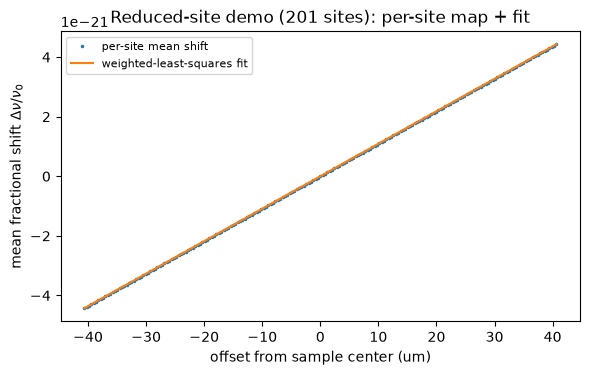

In [6]:
offsets_um = np.array([site.offset_m for site in demo_site_map.sites]) * 1e6
shifts_map = np.array([site.mean_fractional_shift for site in demo_site_map.sites])
fit_line = demo_site_map.slope_per_m * (offsets_um * 1e-6) + demo_site_map.intercept

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(offsets_um, shifts_map, ".", color="C0", markersize=3, label="per-site mean shift")
ax.plot(offsets_um, fit_line, color="C1", label="weighted-least-squares fit")
ax.set_xlabel("offset from sample center (um)")
ax.set_ylabel(r"mean fractional shift $\Delta\nu/\nu_0$")
ax.set_title(f"Reduced-site demo ({N_SITES_DEMO} sites): per-site map + fit")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### 3e. Deterministic gradient vs. stochastic dephasing

`docs/CONVENTIONS.md` section 15 carries a binding labeling rule: a
reader must never mistake the deterministic per-site height gradient
for stochastic decoherence when reading a spread or a `T2*` from this
ensemble regime. The site map's own note, printed verbatim below,
states how to separate the two, using `site_map.slope_per_m` (the
headline, refocusable gradient) against
`site_map.gradient_removed_residual_spread_fractional` (what remains
after subtracting it, the stochastic part).

In [7]:
print(demo_site_map.dispersion_label_note)

lattice_extended dispersion labeling (CONVENTIONS.md section 15, G9 sign-off A4#2): this run's t2_star_s/shift_std_error (MetrologyReport) are computed over the FULL site-and-motional ensemble and therefore include the DETERMINISTIC per-site height gradient (higher/lower sites tick at a systematically different rate -- not a stochastic process, and in principle refocusable) mixed together with any genuine stochastic (motional-quadrature) spread. Use site_map.slope_per_m (the headline gradient) and site_map.total_spread_fractional / site_map.gradient_removed_residual_spread_fractional to separate them: total_spread_fractional is the SAME combined (deterministic + stochastic) number as t2_star_s in fractional-shift units, while gradient_removed_residual_spread_fractional is what remains after subtracting the best-fit linear gradient from each site's own mean shift -- the stochastic-only part. Do not read t2_star_s alone as a decoherence time for this ensemble regime: most of its narrowin

### What Bothwell's two measurements are

The paper reports the redshift gradient two independent ways, and the
comparison below uses both. Method A is a campaign of fourteen
datasets taken over ten days: each dataset images the millimetre-scale
sample in place at 6 um resolution, fits a straight line to frequency
versus position across the pixels, and the fourteen slopes combine
into a weighted mean. The published value then subtracts the small
non-gravity gradients their budget attributes to blackbody radiation,
lattice light, DC Stark, and pixel calibration, leaving the isolated
gravitational gradient of -9.8(2.3)e-20 per mm.

Method B treats two halves of the same sample as two separate clocks
running synchronously. Two regions of about 100 pixels each, one on
either side of the sample center, are compared directly for 92 hours.
Both regions share the same laser and the same environment, so common
noise cancels. The frequency difference divided by the region
separation then gives an independent gradient measurement, corrected
the same way to -1.28(27)e-19 per mm. The two methods share the
apparatus but not the analysis path, which is why the case checks the
prediction against both.

### 3f. The full committed benchmark (the real ~5,945-site grid)

The numbers below are loaded from
`benchmarks/results/bothwell_redshift.json`, the committed output of
`python benchmarks/run_bothwell_redshift.py` run against the real,
full-size computational grid, compared against BOTH of Bothwell's own
published corrected measurements. This is the same `run_pipeline_full`
machinery exercised live above, at the site count that actually
matters for the comparison in section 4. Section 3c already explains
why: at this full ~5,945-site grid, a live run would cost several
minutes, so the committed benchmark's own precomputed output is loaded
here.

In [8]:
full_case_path = Path("..") / "benchmarks" / "results" / "bothwell_redshift.json"
full_report = json.loads(full_case_path.read_text(encoding="utf-8"))
full_case = full_report["bothwell_2022_nature_602_420_redshift_case"]

print(f"case_class:                    {full_case['case_class']!r}")
print(f"full grid site count:          {full_case['n_sites']}")
print(f"predicted slope (full grid):   {full_case['predicted_slope_per_mm']:+.4e} /mm")
print(f"predicted slope (this demo):   {demo_slope_per_mm:+.4e} /mm")
print()
for method_key, label in (
    ("a", "method A (14-dataset campaign)"),
    ("b", "method B (synchronous two-region)"),
):
    measured = full_case[f"measured_slope_method_{method_key}"]
    sigma = full_case[f"sigma_distance_method_{method_key}"]
    verdict = full_case[f"kpi_verdict_method_{method_key}"]
    lo, hi = measured["lo"], measured["hi"]
    print(f"{label}: measured {measured['nominal']:+.2e} [{lo:+.2e}, {hi:+.2e}] /mm")
    print(f"  sigma distance: {sigma:.2f}   kpi_verdict: {verdict}")

case_class:                    'reproducibility'
full grid site count:          5945
predicted slope (full grid):   -1.0900e-19 /mm
predicted slope (this demo):   -1.0900e-19 /mm

method A (14-dataset campaign): measured -9.80e-20 [-1.21e-19, -7.50e-20] /mm
  sigma distance: 0.48   kpi_verdict: MET
method B (synchronous two-region): measured -1.28e-19 [-1.55e-19, -1.01e-19] /mm
  sigma distance: 0.70   kpi_verdict: MET


## 4. The comparison

The reduced-site demo's slope, the full committed benchmark's slope
(essentially identical, since this field-free case is exactly linear
in height and therefore window-independent), and Bothwell's own two
independent corrected measurements, each with its own uncertainty
band.

The class label belongs here, in the same breath as the numbers: this
is `"reproducibility, with the INVERTED-NPL caveat"`
(`benchmarks/RESULTS.md`'s exact wording). The `g/c^2` arithmetic is
textbook, and Bothwell computed it themselves. What this case actually
validates is the extended-sample machinery: the per-site geometry, the
Gaussian-envelope weighting, and the weighted-least-squares fit,
producing the right measured-map slope end to end with zero adjustable
inputs.

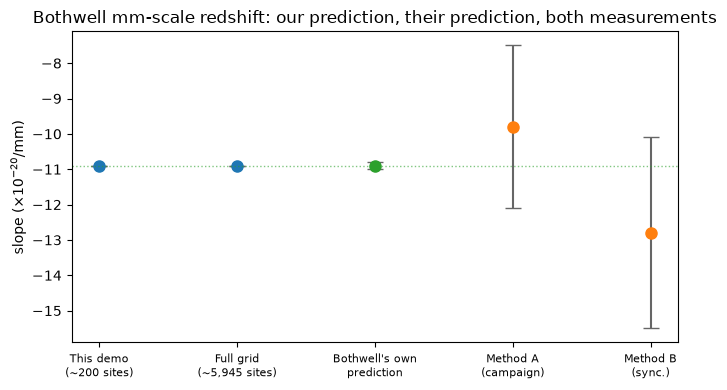

In [9]:
scale = 1e-20
labels = [
    "This demo\n(~200 sites)",
    "Full grid\n(~5,945 sites)",
    "Bothwell's own\nprediction",
    "Method A\n(campaign)",
    "Method B\n(sync.)",
]
# Bothwell's own published prediction (their Table 1 "Known Redshift":
# -10.9e-20/mm with uncertainty below 0.1e-20/mm, computed from their
# USGS-surveyed local g = 9.796 m/s^2). Same arithmetic our engine runs,
# shown as its own point so the chart carries the paper's full record:
# their prediction, their two measurements, and our machinery's output.
bothwell_predicted_per_mm = -10.9e-20
bothwell_predicted_unc = 0.1e-20
nominals = [
    demo_slope_per_mm / scale,
    full_case["predicted_slope_per_mm"] / scale,
    bothwell_predicted_per_mm / scale,
    full_case["measured_slope_method_a"]["nominal"] / scale,
    full_case["measured_slope_method_b"]["nominal"] / scale,
]
lo_err = [
    0.0,
    0.0,
    bothwell_predicted_unc / scale,
    (full_case["measured_slope_method_a"]["nominal"] - full_case["measured_slope_method_a"]["lo"])
    / scale,
    (full_case["measured_slope_method_b"]["nominal"] - full_case["measured_slope_method_b"]["lo"])
    / scale,
]
hi_err = list(lo_err[:3]) + [
    (full_case["measured_slope_method_a"]["hi"] - full_case["measured_slope_method_a"]["nominal"])
    / scale,
    (full_case["measured_slope_method_b"]["hi"] - full_case["measured_slope_method_b"]["nominal"])
    / scale,
]
colors = ["C0", "C0", "C2", "C1", "C1"]

fig, ax = plt.subplots(figsize=(7.0, 4.0))
x_pos = np.arange(5)
ax.errorbar(
    x_pos,
    nominals,
    yerr=[lo_err, hi_err],
    fmt="none",
    ecolor="0.4",
    capsize=6,
)
for xi, nom, color in zip(x_pos, nominals, colors, strict=True):
    ax.plot(xi, nom, "o", color=color, markersize=8)
ax.axhline(bothwell_predicted_per_mm / scale, color="C2", linestyle=":", linewidth=1, alpha=0.6)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel(r"slope ($\times 10^{-20}$/mm)")
ax.set_title("Bothwell mm-scale redshift: our prediction, their prediction, both measurements")
fig.tight_layout()
plt.show()

## 5. What this demonstrates

This case shows the extended-sample machinery, the per-site geometry,
the Gaussian-envelope weighting, and the weighted-least-squares map
fit, reproducing Bothwell's own published measured-map slope end to
end at their surveyed local gravity. Both of their independently
corrected measurements bracket the prediction, with zero adjustable
inputs.

The one caveat worth carrying forward is the mirror image of notebook
07's: the underlying `g/c^2` arithmetic is textbook. The demonstration
here is squarely about the engineering: the geometry, envelope
weighting, and map fitting that reproduce a real published map. This
case's zero-adjustable-input agreement is the `"reproducibility"`
class: it matches Bothwell's own already-published slope using only
the sample geometry and surveyed gravity from section 2, with no
fitted or tuned parameter.

The project's separate blind-prediction count needs a shift nobody had
already computed from the same inputs, a stronger bar this case does
not clear.